In [2]:
import pandas as pd

df = pd.read_csv("../Data/HR_Data.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.shape

(1470, 35)

In [4]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [5]:
df.info


<bound method DataFrame.info of       Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
...   ...       ...                ...        ...                     ...   
1465   36        No  Travel_Frequently        884  Research & Development   
1466   39        No      Travel_Rarely        613  Research & Development   
1467   27        No      Travel_Rarely        155  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education Education

In [6]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [7]:
print("Total Employees:", len(df))
print("Average Age:", round(df["Age"].mean(),2))
print("Average Monthly Income:", round(df["MonthlyIncome"].mean(),2))

Total Employees: 1470
Average Age: 36.92
Average Monthly Income: 6502.93


In [8]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [9]:
attrition_rate = (
    df["Attrition"]
    .value_counts(normalize=True)
    * 100
)

print(attrition_rate)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


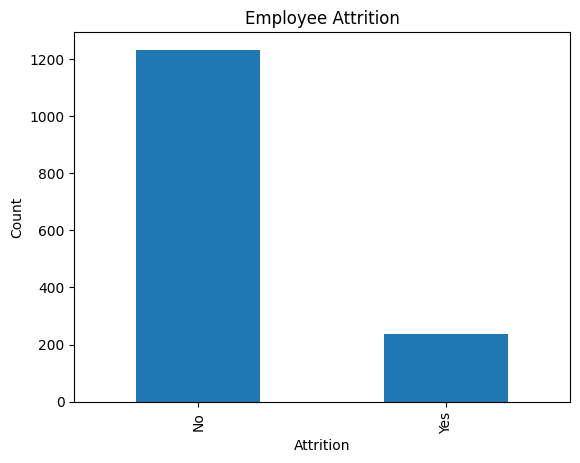

In [12]:
import matplotlib.pyplot as plt

df["Attrition"].value_counts().plot(kind="bar")

plt.title("Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Count")

plt.show()

In [13]:
attrition_count = df["Attrition"].value_counts()

print(attrition_count)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [14]:
attrition_rate = (
    df["Attrition"]
    .value_counts(normalize=True)
    * 100
)

print(attrition_rate)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [15]:
dept_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"]
)

print(dept_attrition)

Attrition                No  Yes
Department                      
Human Resources          51   12
Research & Development  828  133
Sales                   354   92


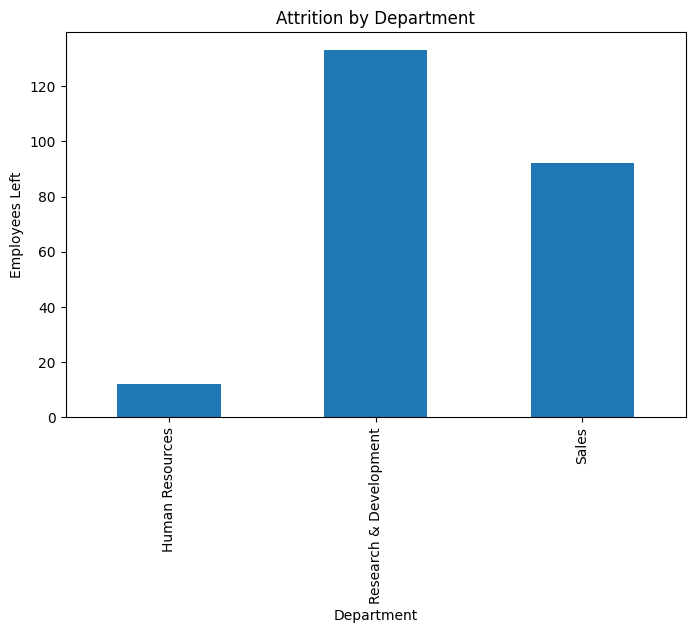

In [16]:
dept_attrition["Yes"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Attrition by Department")
plt.ylabel("Employees Left")
plt.show()

In [17]:
overtime_attrition = pd.crosstab(
    df["OverTime"],
    df["Attrition"]
)

print(overtime_attrition)

Attrition   No  Yes
OverTime           
No         944  110
Yes        289  127


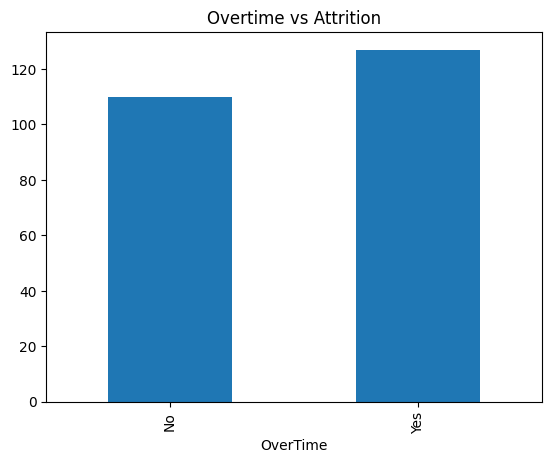

In [18]:
overtime_attrition["Yes"].plot(
    kind="bar"
)

plt.title("Overtime vs Attrition")
plt.show()

In [19]:
jobrole_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"]
)

print(jobrole_attrition)

Attrition                   No  Yes
JobRole                            
Healthcare Representative  122    9
Human Resources             40   12
Laboratory Technician      197   62
Manager                     97    5
Manufacturing Director     135   10
Research Director           78    2
Research Scientist         245   47
Sales Executive            269   57
Sales Representative        50   33


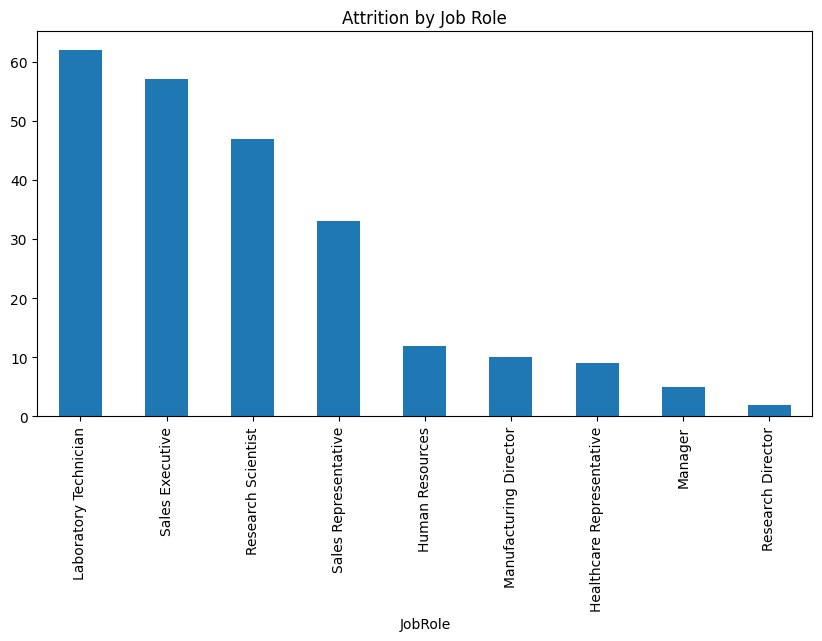

In [20]:
jobrole_attrition["Yes"].sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Attrition by Job Role")
plt.show()

In [21]:
bins = [18,25,35,45,55,65]

labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65"
]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

age_attrition = pd.crosstab(
    df["AgeGroup"],
    df["Attrition"]
)

print(age_attrition)

Attrition   No  Yes
AgeGroup           
18-25       75   40
26-35      490  116
36-45      425   43
46-55      200   26
56-65       39    8


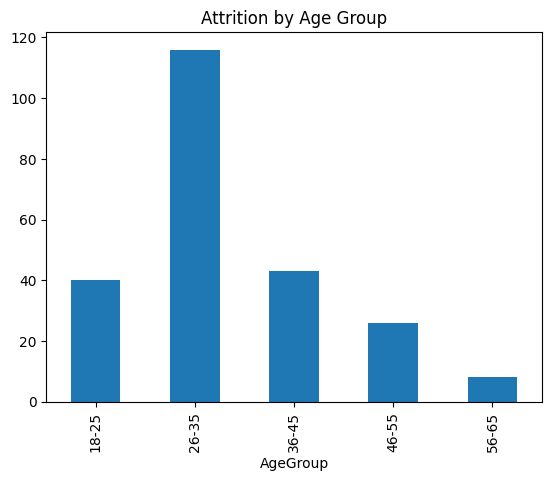

In [22]:
age_attrition["Yes"].plot(
    kind="bar"
)

plt.title("Attrition by Age Group")
plt.show()

In [23]:
print("Total Employees:", len(df))

print("Average Age:",
      round(df["Age"].mean(),2))

print("Average Monthly Income:",
      round(df["MonthlyIncome"].mean(),2))

print("Average Years At Company:",
      round(df["YearsAtCompany"].mean(),2))

Total Employees: 1470
Average Age: 36.92
Average Monthly Income: 6502.93
Average Years At Company: 7.01


In [24]:
attrition_rate = round(
    (df["Attrition"]=="Yes").mean()*100,
    2
)

print("Attrition Rate:", attrition_rate,"%")

Attrition Rate: 16.12 %


In [25]:
print(df.shape)

(1470, 36)


In [26]:
print(df["Department"].value_counts())

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64


In [27]:
print(df["Attrition"].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [28]:
df.to_csv(
    "../PowerBI/HR_Cleaned.csv",
    index=False
)

print("Export Successful")

Export Successful


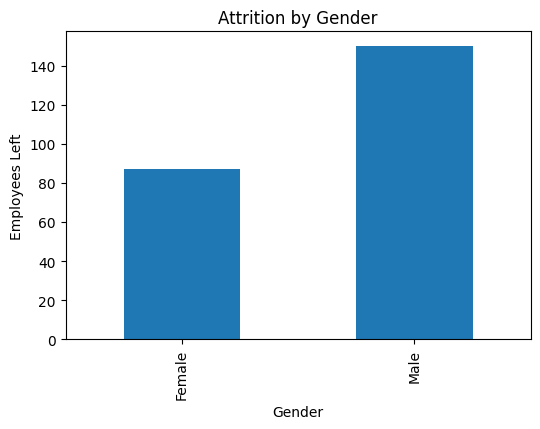

In [29]:
gender_attrition = pd.crosstab(
    df["Gender"],
    df["Attrition"]
)

gender_attrition["Yes"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Attrition by Gender")
plt.ylabel("Employees Left")
plt.show()

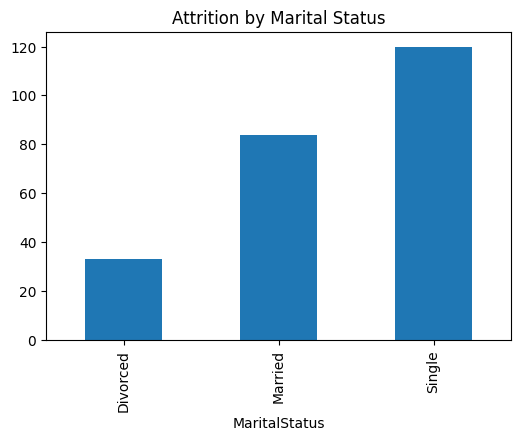

In [30]:
marital_attrition = pd.crosstab(
    df["MaritalStatus"],
    df["Attrition"]
)

marital_attrition["Yes"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Attrition by Marital Status")
plt.show()

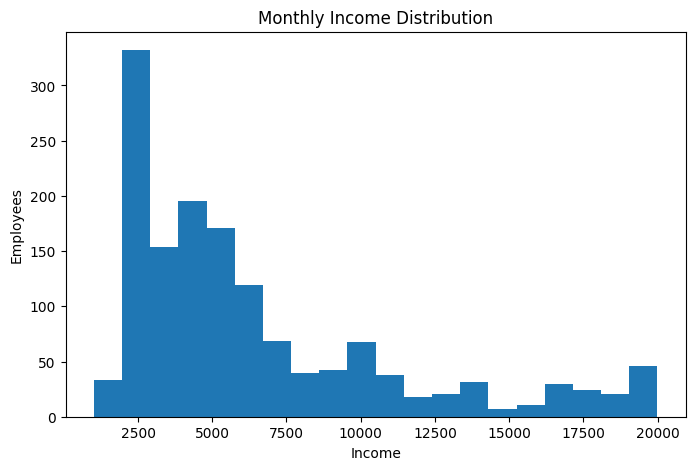

In [31]:
plt.figure(figsize=(8,5))

plt.hist(
    df["MonthlyIncome"],
    bins=20
)

plt.title("Monthly Income Distribution")
plt.xlabel("Income")
plt.ylabel("Employees")

plt.show()